# Stock Price Forecasting with LSTM

### Comparing Baseline and Improved LSTM Architectures for AMZN and CSCO

This project develops and evaluates LSTM-based models for one-step-ahead stock closing price forecasting using historical AMZN and CSCO data.
Lebih kelihatan seperti portfolio daripada tugas UAS.

Two LSTM architectures are developed and compared:

- **Baseline LSTM** — a simple LSTM architecture with 50 units.
- **Improved LSTM** — an extended architecture with 64 LSTM units, Dropout regularization, and an additional Dense layer.

The models are evaluated using:

- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)
- Mean Absolute Percentage Error (MAPE)

### Dataset

The analysis uses historical stock price data for:

- **AMZN** — Amazon
- **CSCO** — Cisco Systems

For this forecasting task, only the **Date** and **Close** variables are used.

## 1. Project Objective

The objective of this project is to investigate whether an LSTM-based deep learning model can learn temporal patterns from historical stock closing prices and generate one-day-ahead forecasts.

The project follows a structured time-series forecasting workflow:

1. Load and inspect the historical stock data
2. Perform exploratory data analysis
3. Select the Date and Close variables
4. Split the data into training and test sets
5. Normalize the closing prices
6. Create time-series sequences using a 5-day window
7. Split the training data into training and validation sets
8. Train a baseline LSTM model
9. Develop an improved LSTM architecture
10. Evaluate and compare both models

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import warnings
warnings.filterwarnings("ignore")

## 2. Data loading and Initial Inspection

In [3]:
amzn = pd.read_csv('AMZN.csv')
csco = pd.read_csv('CSCO.csv')

print("Jumlah Baris AMZN:", amzn.shape[0])
print("Jumlah Kolom AMZN:", amzn.shape[1])
print("Jumlah Baris CSCO:", csco.shape[0])
print("Jumlah Kolom CSCO:", csco.shape[1])

Jumlah Baris AMZN: 5758
Jumlah Kolom AMZN: 7
Jumlah Baris CSCO: 7589
Jumlah Kolom CSCO: 7


In [4]:
amzn.head()
csco.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1990-02-16,0.0,0.079861,0.073785,0.077257,0.059806,940636800
1,1990-02-20,0.0,0.079861,0.074653,0.079861,0.061822,151862400
2,1990-02-21,0.0,0.078993,0.075521,0.078125,0.060478,70531200
3,1990-02-22,0.0,0.081597,0.078993,0.078993,0.061150,45216000
4,1990-02-23,0.0,0.079861,0.078125,0.078559,0.060814,44697600


## 3. Data Quality Check

In [9]:
print("AMZN shape:")
amzn.shape

AMZN shape:


(5758, 7)

In [10]:
print("\nCSCO shape:")
csco.shape


CSCO shape:


(7589, 7)

In [7]:
amzn.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,5758,5758,2020-04-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Open,5758.0,NaN,NaN,NaN,340.458153,523.365374,1.40625,37.460001,81.965,335.267494,2173.070068
High,5758.0,NaN,NaN,NaN,344.156408,528.138556,1.447917,38.334999,83.52,337.537491,2185.949951
Low,5758.0,NaN,NaN,NaN,336.34439,517.726971,1.3125,36.812499,79.875,331.727501,2161.120117
Close,5758.0,NaN,NaN,NaN,340.41758,523.140207,1.395833,37.5625,81.599998,334.290001,2170.219971
Adj Close,5758.0,NaN,NaN,NaN,340.41758,523.140207,1.395833,37.5625,81.599998,334.290001,2170.219971
Volume,5758.0,NaN,NaN,NaN,7556093.938868,7325903.871223,487200.0,3685525.0,5692450.0,8594350.0,104329200.0


In [8]:
csco.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,7589,7589,2020-04-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Open,7589.0,NaN,NaN,NaN,20.404527,14.915392,0.0,8.444445,19.700001,27.129999,81.4375
High,7589.0,NaN,NaN,NaN,20.682047,15.133191,0.072917,8.583333,19.9375,27.41,82.0
Low,7589.0,NaN,NaN,NaN,20.116294,14.676149,0.068576,8.326389,19.440001,26.83,79.0625
Close,7589.0,NaN,NaN,NaN,20.399541,14.906589,0.071181,8.479167,19.68,27.120001,80.0625
Adj Close,7589.0,NaN,NaN,NaN,16.9452,13.253297,0.055102,6.563846,15.311988,21.845076,61.977535
Volume,7589.0,NaN,NaN,NaN,56801875.97839,41687268.433891,806400.0,32450600.0,48988500.0,68226500.0,940636800.0


## 4. Data Preparation

### Feature selection
According to the forecasting task, only the trading date and closing price are used as model inputs

In [9]:
amzn = amzn[['Date','Close']]
csco = csco[['Date','Close']]

In [23]:
# Convert date into datetime
amzn['Date'] = pd.to_datetime(amzn['Date'])
csco['Date'] = pd.to_datetime(csco['Date'])

# sort date chronologically
amzn = amzn.sort_values('Date').reset_index(drop=True)
csco = csco.sort_values('Date').reset_index(drop=True)

amzn.head()
csco.head()

,Date,Close
0,1990-02-16,0.077257
1,1990-02-20,0.079861
2,1990-02-21,0.078125
3,1990-02-22,0.078993
4,1990-02-23,0.078559


## 5. Exploratory Data Analysis
The closing price series are visualized to examine the overall temporal behavior of AMZN n CSCO before model development

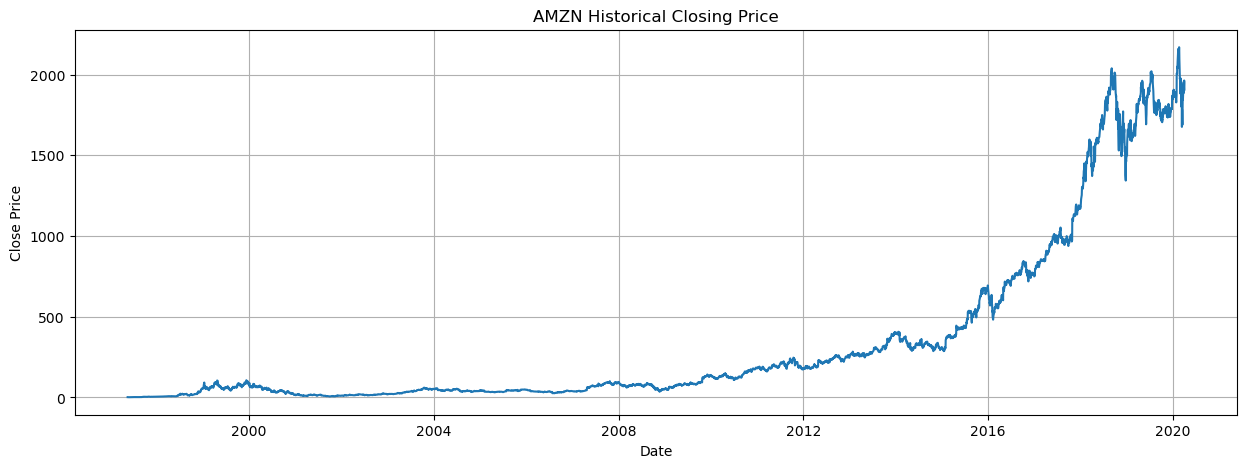

In [24]:
# Time Series visualization - AMZN
plt.figure(figsize=(15,5))

plt.plot(
    amzn['Date'],
    amzn['Close']
)

plt.title("AMZN Historical Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True)

plt.show()


Time-series visualization of AMZN historical closing prices reveals a long-term upward trend accompanied by fluctuations throughout the observation period. The stock experienced relatively gradual price movements during the early period, followed by stronger growth from approximately 2015 onward. The increasing magnitude of price movements highlights the temporal variability of the stock price and supports the use of time-series forecasting techniques such as LSTM.

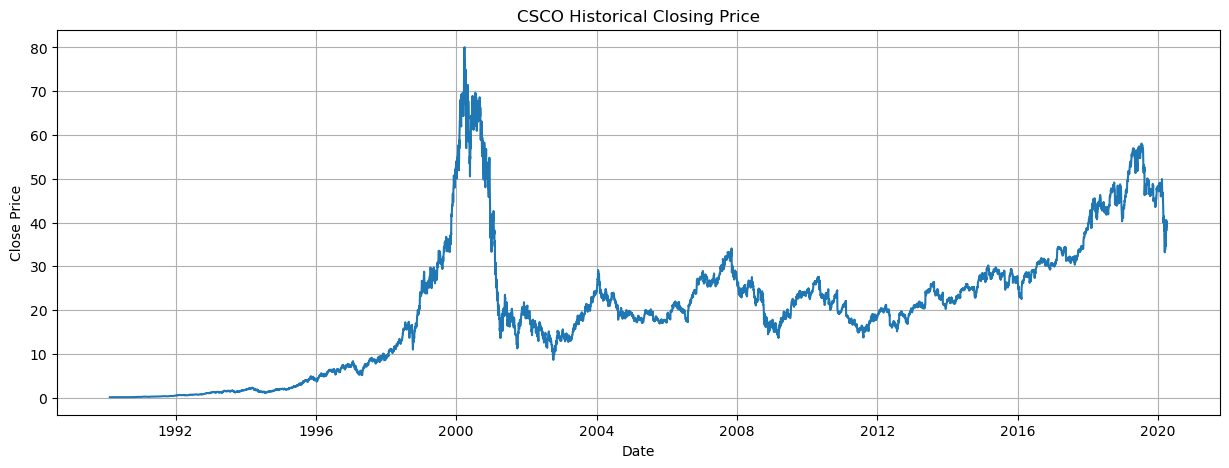

In [25]:
# Time Series visualization - csco
plt.figure(figsize=(15,5))

plt.plot(
    csco['Date'],
    csco['Close']
)

plt.title("CSCO Historical Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True)

plt.show()

Time-series visualization of CSCO historical closing prices shows significant 
fluctuations throughout the observation period. The stock experienced a substantial increase between 1997 and 2000., followed by a sharp decline after its peak. 
From 2002 to 2016, the price exhibited relatively lower and fluctuating movements,
before showing a more consistent upward trend toward 2020. These temporal patterns 
and fluctuations provide a basis for applying time-series forecasting
techniques such as LSTM.

## 6. Train-Test Split
To preserve the chronological structure of the time-series data, the datasets are split chronologically rather than randomly.

The final 252 trading days, approximately representing the last year of observations, are reserved as the test set. The remaining observations are used for model development.


In [26]:
# karena test set = satu tahun terakhir (anggap 252 days)
TEST_DAYS = 252

def train_test_split_ts(df):

    train = df[:-TEST_DAYS]
    test = df[-TEST_DAYS:]

    return train,test

In [27]:
amzn_train, amzn_test = train_test_split_ts(amzn)

csco_train, csco_test = train_test_split_ts(csco)

In [28]:
# scaling
def scaling(train,test):

    scaler = MinMaxScaler()

    train_scaled = scaler.fit_transform(
        train[['Close']]
    )

    test_scaled = scaler.transform(
        test[['Close']]
    )

    return train_scaled,test_scaled,scaler

In [29]:
amzn_train_scaled, amzn_test_scaled, amzn_scaler = scaling(
    amzn_train,
    amzn_test
)

csco_train_scaled, csco_test_scaled, csco_scaler = scaling(
    csco_train,
    csco_test
)

## 7. Time-Series Windowing

To transform the sequential stock data into supervised learning samples, a sliding-window approach is applied.

A window size of 5 is used, meaning that the model receives the previous 5 trading days as input to predict the closing price of the following trading day.

- **Window size:** 5 trading days
- **Forecast horizon:** 1 trading day

In [30]:
# windowing , sesuai soal window size = 5, hroizon =1
WINDOW_SIZE = 5

def create_window(data, window=WINDOW_SIZE):

    X = []
    y = []

    for i in range(len(data) - window):
        X.append(data[i:i + window])
        y.append(data[i + window])

    return np.array(X), np.array(y)

In [31]:
X_train_amzn, y_train_amzn = create_window(
    amzn_train_scaled
)

X_test_amzn, y_test_amzn = create_window(
    amzn_test_scaled
)

X_train_csco, y_train_csco = create_window(
    csco_train_scaled
)

X_test_csco, y_test_csco = create_window(
    csco_test_scaled
)

In [32]:
# shape check
print("AMZN")
print("X_train:", X_train_amzn.shape)
print("y_train:", y_train_amzn.shape)
print("X_test :", X_test_amzn.shape)
print("y_test :", y_test_amzn.shape)

print("\nCSCO")
print("X_train:", X_train_csco.shape)
print("y_train:", y_train_csco.shape)
print("X_test :", X_test_csco.shape)
print("y_test :", y_test_csco.shape)

AMZN
X_train: (5501, 5, 1)
y_train: (5501, 1)
X_test : (247, 5, 1)
y_test : (247, 1)

CSCO
X_train: (7332, 5, 1)
y_train: (7332, 1)
X_test : (247, 5, 1)
y_test : (247, 1)


## 8. Train-Validation Split

The training sequences are divided chronologically into training and validation sets using a 90:10 ratio.

A chronological split is maintained to preserve the temporal structure of the stock price data and avoid using future observations to train the model.

In [33]:
# Train validation split
def train_validation_split(X,y):

    split_idx = int(len(X)*0.9)

    X_train = X[:split_idx]
    y_train = y[:split_idx]

    X_val = X[split_idx:]
    y_val = y[split_idx:]

    return X_train,X_val,y_train,y_val

In [34]:
# amzn
X_train_amzn, X_val_amzn, y_train_amzn, y_val_amzn = \
train_validation_split(
    X_train_amzn,
    y_train_amzn
)

# csco
X_train_csco, X_val_csco, y_train_csco, y_val_csco = \
train_validation_split(
    X_train_csco,
    y_train_csco
)

In [35]:
print("AMZN")
print(X_train_amzn.shape)
print(X_val_amzn.shape)

print("\nCSCO")
print(X_train_csco.shape)
print(X_val_csco.shape)

AMZN
(4950, 5, 1)
(551, 5, 1)

CSCO
(6598, 5, 1)
(734, 5, 1)


## 9. Baseline LSTM Model

The baseline model is designed as a simple LSTM architecture to establish a performance benchmark.

The architecture consists of:

- LSTM layer with 50 units
- ReLU activation function
- Dense output layer with 1 unit
- Adam optimizer
- Mean Squared Error (MSE) loss
- Mean Absolute Error (MAE) as an evaluation metric

The baseline model serves as a reference point for evaluating the improved architecture.

In [36]:
def baseline_model():

    model = Sequential()

    model.add(
        LSTM(
            units=50,
            activation='relu',
            input_shape=(5,1)
        )
    )

    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model

In [37]:
# baseline model amzn
baseline_amzn = baseline_model()

# baseline model csco
baseline_csco = baseline_model()

In [38]:
# summary amzn
baseline_amzn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

### Baseline Model

This is the first LSTM model used in this project.

The model uses 50 LSTM units and one Dense layer to predict the next closing price.

This model will be compared with the improved LSTM model later.

## 10. Baseline Model Training

The baseline LSTM models are trained separately on the AMZN and CSCO training datasets.

Early stopping is used to stop training when the validation loss no longer improves, while the best model weights are restored.

In [39]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history_amzn = baseline_amzn.fit(
    X_train_amzn,
    y_train_amzn,
    validation_data=(
        X_val_amzn,
        y_val_amzn
    ),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0031 - mae: 0.0222 - val_loss: 0.0115 - val_mae: 0.0899
Epoch 2/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.5199e-05 - mae: 0.0025 - val_loss: 0.0101 - val_mae: 0.0844
Epoch 3/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.3351e-05 - mae: 0.0022 - val_loss: 0.0084 - val_mae: 0.0760
Epoch 4/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.3216e-05 - mae: 0.0023 - val_loss: 0.0072 - val_mae: 0.0703
Epoch 5/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.2851e-05 - mae: 0.0022 - val_loss: 0.0069 - val_mae: 0.0686
Epoch 6/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.2767e-05 - mae: 0.0023 - val_loss: 0.0080 - val_mae: 0.0756
Epoch 7/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.3302e-05 - mae: 0.0023 - val_loss: 0.0071 - val_mae: 0.0708
Epoch 8/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.2735e-05 - mae: 0.0022 - val_loss: 0.0054 - val_mae: 0.0607
Epoch 9/100
155/15

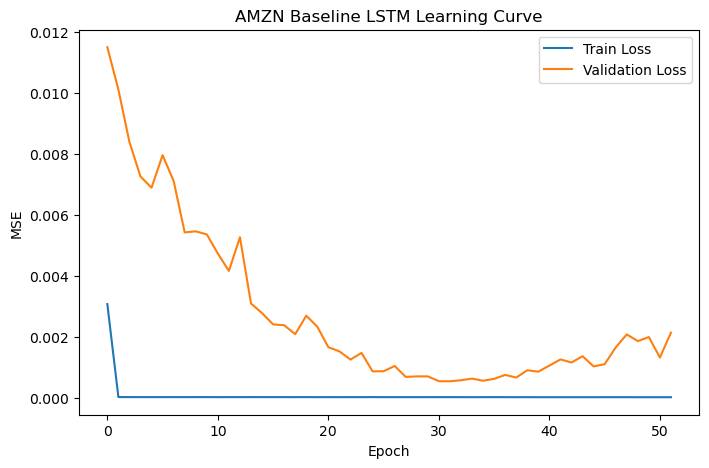

In [40]:
# plot learning curve
plt.figure(figsize=(8,5))

plt.plot(history_amzn.history['loss'],
         label='Train Loss')

plt.plot(history_amzn.history['val_loss'],
         label='Validation Loss')

plt.title('AMZN Baseline LSTM Learning Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()

plt.show()

### Baseline model training - csco

In [41]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history_csco = baseline_csco.fit(
    X_train_csco,
    y_train_csco,
    validation_data=(
        X_val_csco,
        y_val_csco
    ),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0062 - mae: 0.0337 - val_loss: 1.0363e-04 - val_mae: 0.0072
Epoch 2/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.2311e-04 - mae: 0.0065 - val_loss: 7.9481e-05 - val_mae: 0.0061
Epoch 3/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.1874e-04 - mae: 0.0063 - val_loss: 7.9482e-05 - val_mae: 0.0063
Epoch 4/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.2066e-04 - mae: 0.0064 - val_loss: 1.1392e-04 - val_mae: 0.0086
Epoch 5/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.1679e-04 - mae: 0.0063 - val_loss: 1.0202e-04 - val_mae: 0.0076
Epoch 6/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.1239e-04 - mae: 0.0060 - val_loss: 8.0848e-05 - val_mae: 0.0064
Epoch 7/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.1569e-04 - mae: 0.0063 - val_loss: 1.0028e-04 - val_mae: 0.0077
Epoch 8/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.1704e-04 - mae: 0.0065 - val_loss: 7.0941e-05 - val

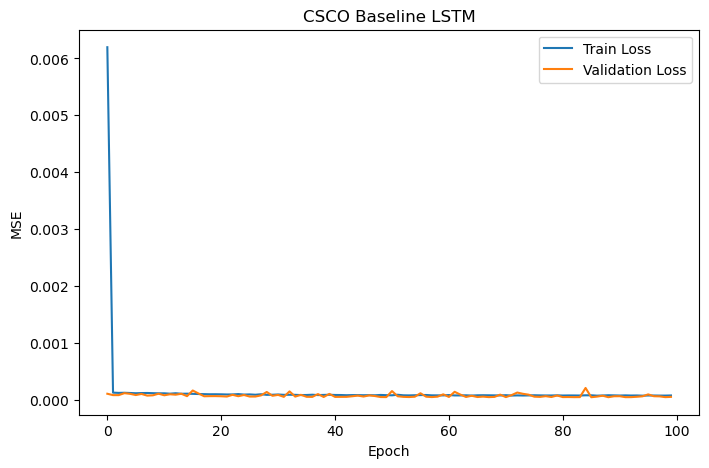

In [42]:
plt.figure(figsize=(8,5))

plt.plot(history_csco.history['loss'],
         label='Train Loss')

plt.plot(history_csco.history['val_loss'],
         label='Validation Loss')

plt.title('CSCO Baseline LSTM')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()

plt.show()

## 11. Improved LSTM Model

The baseline model is extended by increasing the LSTM capacity and adding regularization.

The improved architecture consists of:

- LSTM layer with 64 units
- Dropout layer with a rate of 0.1
- Dense layer with 16 units and ReLU activation
- Dense output layer with 1 unit

The additional layers are introduced to give the model more capacity to learn temporal patterns while using Dropout to reduce the risk of overfitting.

In [43]:
from tensorflow.keras.optimizers import Adam

def improved_model():

    model = Sequential()

    model.add(
        LSTM(
            units=64,
            activation='relu',
            input_shape=(5,1)
        )
    )

    model.add(Dropout(0.1))

    model.add(Dense(
        16,
        activation='relu'
    ))

    model.add(Dense(1))

    model.compile(
        optimizer=Adam(),
        loss='mse',
        metrics=['mae']
    )

    return model

## 12. Improved Model Training

In [44]:
improved_amzn = improved_model()

improved_amzn.summary()

history_improved_amzn = improved_amzn.fit(
    X_train_amzn,
    y_train_amzn,
    validation_data=(X_val_amzn, y_val_amzn),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,953 (70.13 KB)

 Trainable params: 17,953 (70.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0019 - mae: 0.0232 - val_loss: 0.0011 - val_mae: 0.0281
Epoch 2/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.1927e-04 - mae: 0.0070 - val_loss: 0.0014 - val_mae: 0.0264
Epoch 3/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 8.7313e-05 - mae: 0.0057 - val_loss: 0.0034 - val_mae: 0.0399
Epoch 4/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 7.1421e-05 - mae: 0.0050 - val_loss: 0.0020 - val_mae: 0.0330
Epoch 5/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 7.2332e-05 - mae: 0.0052 - val_loss: 0.0053 - val_mae: 0.0515
Epoch 6/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 6.2201e-05 - mae: 0.0048 - val_loss: 0.0058 - val_mae: 0.0539
Epoch 7/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 5.6489e-05 - mae: 0.0045 - val_loss: 0.0053 - val_mae: 0.0514
Epoch 8/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 6.3577e-05 - mae: 0.0048 - val_loss: 0.0052 - val_mae: 0.0506
Epoch 9/200


In [45]:
improved_csco = improved_model()

improved_csco.summary()

history_improved_csco = improved_csco.fit(
    X_train_csco,
    y_train_csco,
    validation_data=(
        X_val_csco,
        y_val_csco
    ),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,953 (70.13 KB)

 Trainable params: 17,953 (70.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0050 - mae: 0.0348 - val_loss: 2.5435e-04 - val_mae: 0.0138
Epoch 2/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 4.8842e-04 - mae: 0.0153 - val_loss: 9.9606e-05 - val_mae: 0.0075
Epoch 3/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.9970e-04 - mae: 0.0133 - val_loss: 4.1341e-04 - val_mae: 0.0185
Epoch 4/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.5299e-04 - mae: 0.0125 - val_loss: 1.6781e-04 - val_mae: 0.0103
Epoch 5/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.3485e-04 - mae: 0.0116 - val_loss: 1.6993e-04 - val_mae: 0.0099
Epoch 6/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 2.9785e-04 - mae: 0.0111 - val_loss: 3.1614e-04 - val_mae: 0.0163
Epoch 7/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 2.7356e-04 - mae: 0.0107 - val_loss: 8.3453e-05 - val_mae: 0.0064
Epoch 8/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 2.5488e-04 - mae: 0.0101 - val_loss: 9.9265e-0

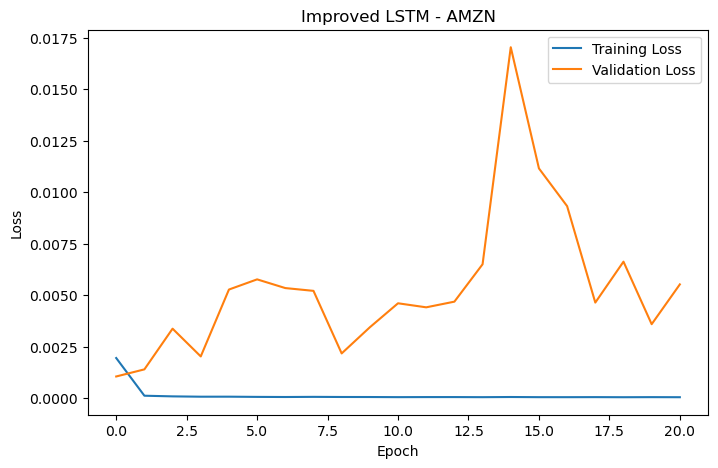

In [46]:
# Plot learning curve 2 amzn
plt.figure(figsize=(8,5))

plt.plot(history_improved_amzn.history['loss'], label='Training Loss')
plt.plot(history_improved_amzn.history['val_loss'], label='Validation Loss')

plt.title('Improved LSTM - AMZN')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

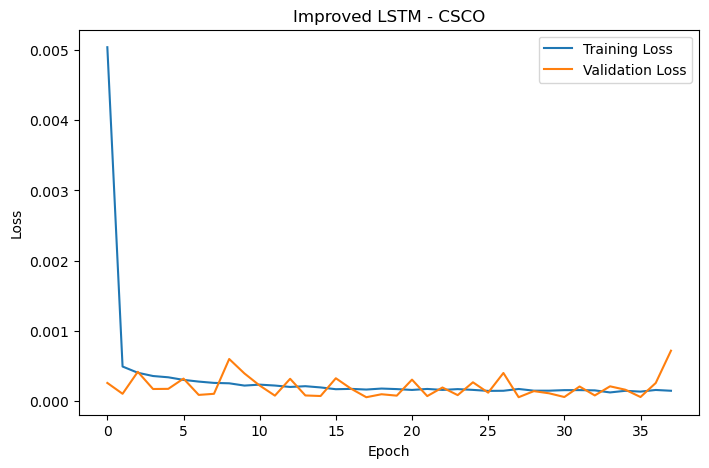

In [47]:
# Plot learning curve 2 csco
plt.figure(figsize=(8,5))

plt.plot(history_improved_csco.history['loss'], label='Training Loss')
plt.plot(history_improved_csco.history['val_loss'], label='Validation Loss')

plt.title('Improved LSTM - CSCO')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

## 13. Model Evaluation


In [37]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

def evaluate_model(model, X_test, y_test, scaler, dataset_name, model_name):
    # Predict
    y_pred = model.predict(X_test)

    # Balikin dari skala 0-1 ke harga asli
    y_test_actual = scaler.inverse_transform(y_test)
    y_pred_actual = scaler.inverse_transform(y_pred)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

    result = {
        "Dataset": dataset_name,
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape
    }

    return result, y_test_actual, y_pred_actual

In [38]:
# evaluasi AMZN
result_amzn_baseline, y_amzn_actual, y_amzn_pred_baseline = evaluate_model(
    baseline_amzn,
    X_test_amzn,
    y_test_amzn,
    amzn_scaler,
    "AMZN",
    "Baseline LSTM"
)

result_amzn_improved, y_amzn_actual, y_amzn_pred_improved = evaluate_model(
    improved_amzn,
    X_test_amzn,
    y_test_amzn,
    amzn_scaler,
    "AMZN",
    "Improved LSTM"
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [ ]:
# evaluasi CSCO
result_csco_baseline, y_csco_actual, y_csco_pred_baseline = evaluate_model(
    baseline_csco,
    X_test_csco,
    y_test_csco,
    csco_scaler,
    "CSCO",
    "Baseline LSTM"
)

result_csco_improved, y_csco_actual, y_csco_pred_improved = evaluate_model(
    improved_csco,
    X_test_csco,
    y_test_csco,
    csco_scaler,
    "CSCO",
    "Improved LSTM"
)

In [40]:
# Tabel hasil
evaluation_results = pd.DataFrame([
    result_amzn_baseline,
    result_amzn_improved,
    result_csco_baseline,
    result_csco_improved
])

evaluation_results

,Dataset,Model,RMSE,MAE,MAPE (%)
0,AMZN,Baseline LSTM,61.914561,45.018370,2.414313
1,AMZN,Improved LSTM,50.930036,35.069274,1.881757
2,CSCO,Baseline LSTM,1.048321,0.714963,1.548548
3,CSCO,Improved LSTM,1.454481,1.108203,2.312323


## Key Findings

- For AMZN, the improved LSTM reduced RMSE by approximately 17.7% compared with the baseline model.
- AMZN MAE decreased by approximately 22.1%.
- For CSCO, the baseline LSTM achieved lower RMSE, MAE, and MAPE than the improved architecture.
- The results show that the impact of architectural improvements varies across datasets.

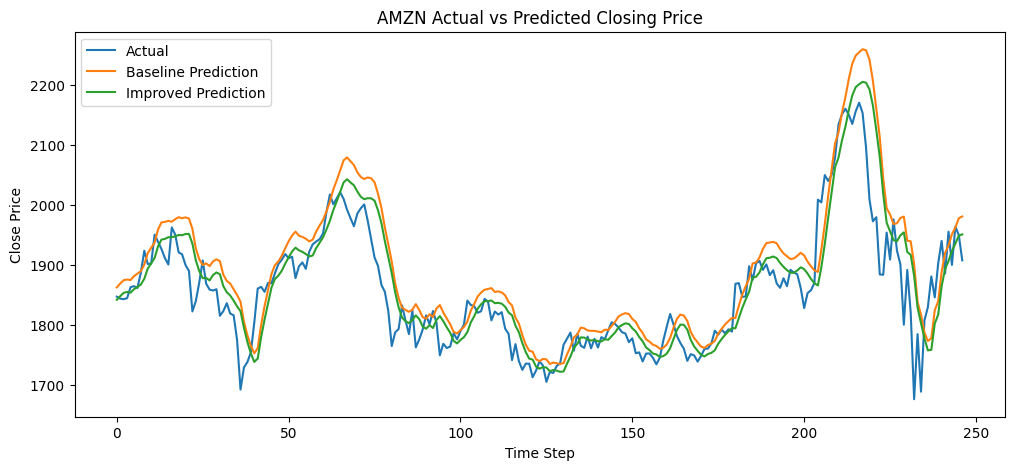

In [41]:
# plot prediksi vs aktual amzn
plt.figure(figsize=(12,5))
plt.plot(y_amzn_actual, label="Actual")
plt.plot(y_amzn_pred_baseline, label="Baseline Prediction")
plt.plot(y_amzn_pred_improved, label="Improved Prediction")
plt.title("AMZN Actual vs Predicted Closing Price")
plt.xlabel("Time Step")
plt.ylabel("Close Price")
plt.legend()
plt.show()

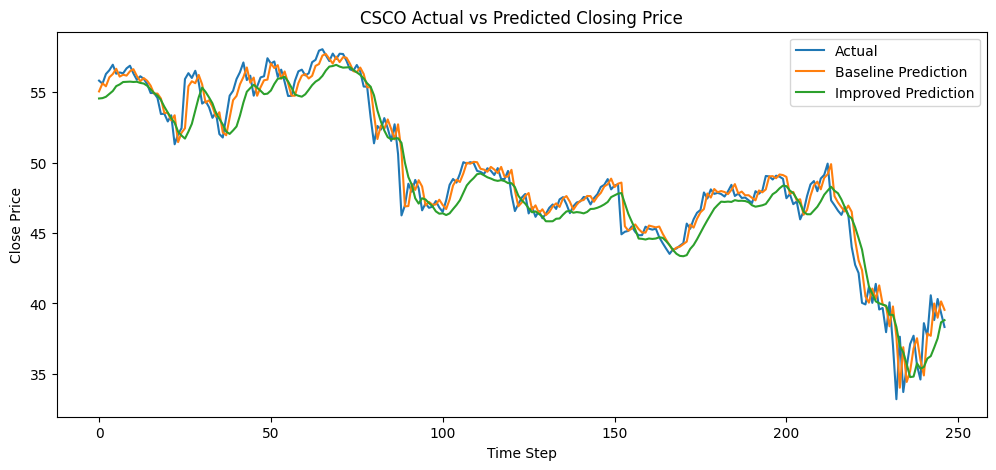

In [42]:
# plot prediksi vs aktual csco
plt.figure(figsize=(12,5))
plt.plot(y_csco_actual, label="Actual")
plt.plot(y_csco_pred_baseline, label="Baseline Prediction")
plt.plot(y_csco_pred_improved, label="Improved Prediction")
plt.title("CSCO Actual vs Predicted Closing Price")
plt.xlabel("Time Step")
plt.ylabel("Close Price")
plt.legend()
plt.show()

In [45]:
print("Epoch :", len(history_improved_amzn.history['loss']))

print("Final Train Loss :", history_improved_amzn.history['loss'][-1])
print("Final Val Loss   :", history_improved_amzn.history['val_loss'][-1])

print("Final Train MAE :", history_improved_amzn.history['mae'][-1])
print("Final Val MAE   :", history_improved_amzn.history['val_mae'][-1])

Epoch : 20
Final Train Loss : 5.428668373497203e-05
Final Val Loss   : 0.0005722206551581621
Final Train MAE : 0.004561326000839472
Final Val MAE   : 0.0199960395693779
